## Multi-view hand triangulation

Merges `hand_triangulation.ipynb` (h5 calibration averaging + undistortion + MediaPipe extraction)
and `triangulation.ipynb` (essential-matrix relative pose estimation + triangulation), generalized
from 2 cameras to N cameras using real averaged intrinsics instead of synthetic ones. Reusable logic
lives in `hand_multiview.py`; this notebook only orchestrates the 5 steps below. Cameras are assumed
static for the whole session -- poses are estimated once (step 3) and reused unchanged to triangulate
every frame (step 5).

Deliberately does **not** reuse `h5_explore.ipynb`'s pipeline: that notebook's ground-truth extrinsics
belong to a different 7-camera rig (`cam00`..`cam06`) than the actual 4-camera recording rig used here
(`cam0`..`cam3`), so only the h5's averaged *intrinsics* are transferable -- real extrinsics for this
rig must be estimated from the footage itself, as in `triangulation.ipynb`.

1. Load h5 calibration, average intrinsics (skip `cam02`).
2. Undistort + run MediaPipe Hands over all frames of a session, caching results as JSON.
3. Estimate the 4 cameras' relative poses from a pooled subset of frames (essential matrix for a
   reference pair, then PnP chaining for the rest) so everything lands in one consistent scale.
4. Start a viser server and visualize the estimated camera layout.
5. Triangulate every frame and animate the reconstructed hand skeleton in the same viser scene.

Note: the resulting coordinate frame has an arbitrary scale and up-direction -- there is no gravity/
world reference available for this rig (unlike `h5_explore.ipynb`'s ground-truth-calibrated case).

In [1]:
import os
import numpy as np

import hand_multiview as hmv

H5_PATH = 'tmp/Testdata.h5'
SESSION_DIR = 'recordings/sign_capture_20260702_202231_iso800_shutter3000us'


### Step 1: calibration averaging

In [2]:
cal, camera_ids = hmv.load_chameleon_calibration(H5_PATH)
avg = hmv.average_intrinsics(cal, camera_ids, skip_ids={'cam02'})
print('camera_ids:', camera_ids)
print('averaged K (calibration resolution):')
print(avg['K'])
print('averaged dist:', avg['dist'])
print(f"calibration size: {avg['width']}x{avg['height']}")


camera_ids: ['cam00', 'cam01', 'cam02', 'cam03', 'cam04', 'cam05', 'cam06']
averaged K (calibration resolution):
[[2.00587455e+03 0.00000000e+00 1.69477191e+03]
 [0.00000000e+00 2.00587455e+03 9.44842662e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
averaged dist: [-2.83168554e-01  3.15461275e+01 -2.19885910e-04 -2.01498427e-04
  3.54113164e+00 -1.63159291e-01  3.18571472e+01  1.03186779e+01]
calibration size: 3360.0x1890.0


In [3]:
# The h5 calibration sensor size differs from the actual session's recorded resolution --
# rescale K accordingly (fx, fy, cx, cy scale with resolution; dist is unaffected).
sample_cam = hmv.discover_cameras(SESSION_DIR)[0]
sample_frame = hmv.discover_frames(SESSION_DIR, sample_cam)[0]
sample_w, sample_h = hmv.get_image_size(SESSION_DIR, sample_cam, sample_frame)

K_avg = hmv.scale_intrinsics(avg['K'], (avg['width'], avg['height']), (sample_w, sample_h))
dist_avg = avg['dist']
w_avg, h_avg = float(sample_w), float(sample_h)

print(f'session frame size: {sample_w}x{sample_h}')
print('K before rescale:')
print(avg['K'])
print('K after rescale:')
print(K_avg)


session frame size: 3840x2160
K before rescale:
[[2.00587455e+03 0.00000000e+00 1.69477191e+03]
 [0.00000000e+00 2.00587455e+03 9.44842662e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
K after rescale:
[[2.29242806e+03 0.00000000e+00 1.93688218e+03]
 [0.00000000e+00 2.29242806e+03 1.07982018e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


### Step 2: discover cameras/frames, undistort + run MediaPipe Hands (cached)

In [4]:
cam_ids = hmv.discover_cameras(SESSION_DIR)
frames_by_cam = hmv.discover_all_frames(SESSION_DIR, cam_ids)
for cam_id in cam_ids:
    print(cam_id, len(frames_by_cam[cam_id]), 'frames')


cam0 280 frames
cam1 280 frames
cam2 280 frames
cam3 280 frames


In [5]:
landmarks, confidence = hmv.extract_hand_landmarks_for_session(
    SESSION_DIR, K_avg, dist_avg, cam_ids=cam_ids, force=False,
)


Loaded cached landmarks/confidence from recordings/sign_capture_20260702_202231_iso800_shutter3000us\aligned


In [6]:
for cam_id in cam_ids:
    total = len(frames_by_cam[cam_id])
    detected = len(landmarks.get(cam_id, {}))
    pct = 100.0 * detected / total if total else 0.0
    print(f'{cam_id}: {detected}/{total} frames with a detected hand ({pct:.1f}%)')


cam0: 275/280 frames with a detected hand (98.2%)
cam1: 173/280 frames with a detected hand (61.8%)
cam2: 276/280 frames with a detected hand (98.6%)
cam3: 148/280 frames with a detected hand (52.9%)


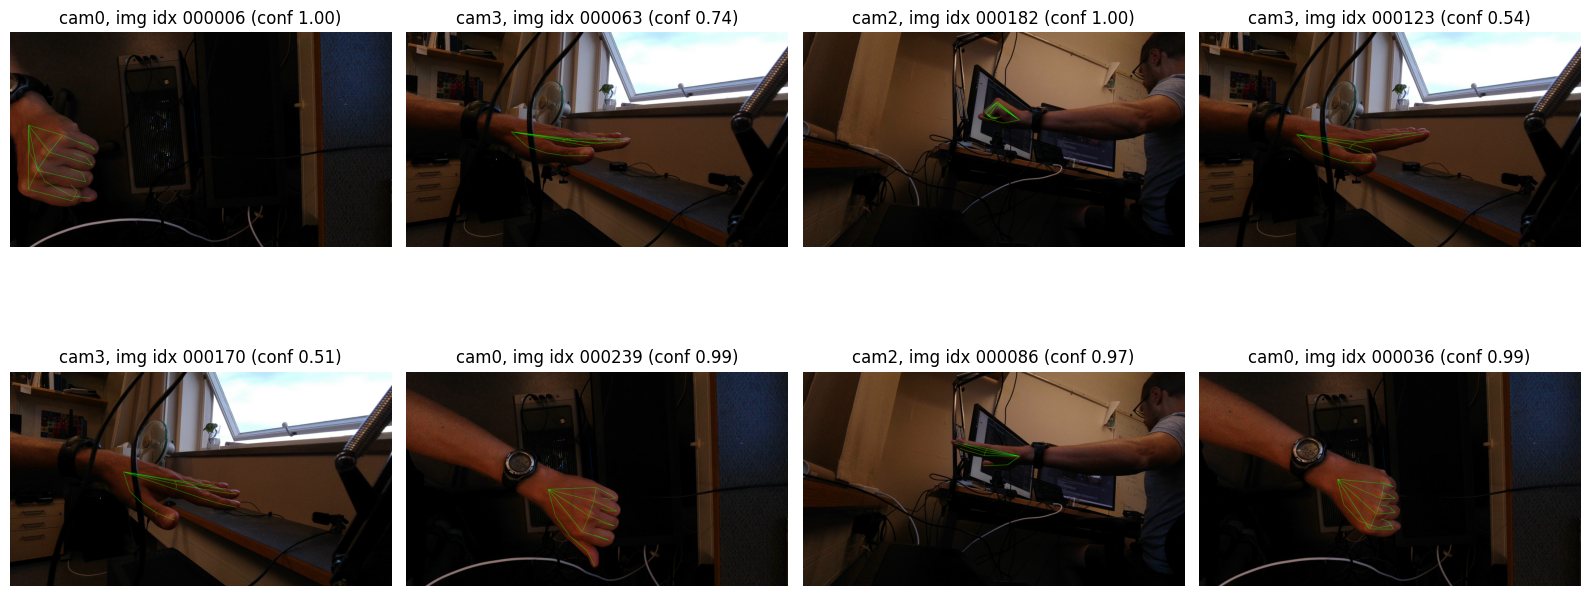

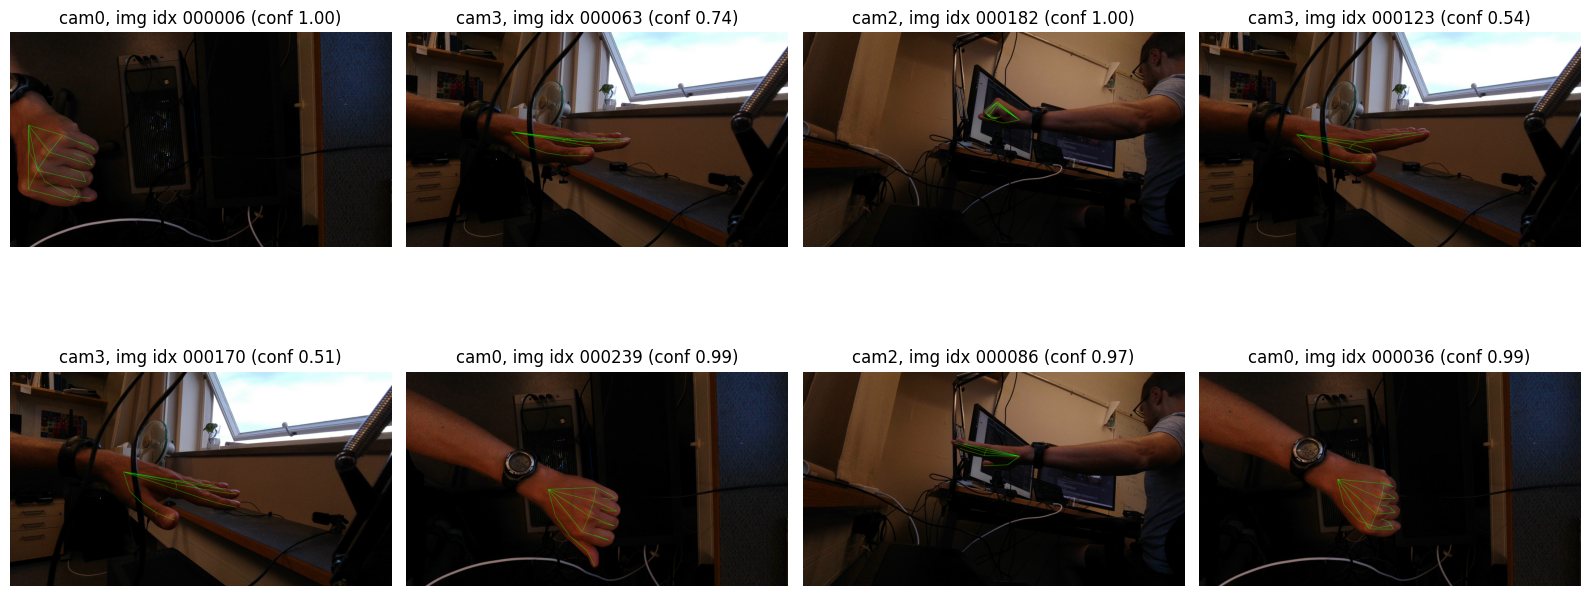

In [7]:
# Sanity check: a random selection of undistorted frames with the MediaPipe skeleton
# overlaid and the per-frame handedness confidence, to eyeball detection quality
# across cameras before trusting the cached landmarks/confidence for pose estimation.
samples = hmv.sample_detected_frames(landmarks, cam_ids, n_samples=8)
hmv.plot_sample_detections(SESSION_DIR, landmarks, confidence, K_avg, dist_avg, w_avg, h_avg, samples)


### Step 3: estimate camera poses (reference pair + PnP chaining)

Pose estimation (reference-pair essential matrix + ranking) uses **wrist-landmark-only**
correspondences (`hmv.POSE_ESTIMATION_LANDMARK_IDS`): fingertip landmarks dominate the full
21-point set but carry far more noise from fast motion/occlusion during signing, which was
swamping the fundamental-matrix RANSAC fit (roughly 3x lower inlier ratio than wrist-only in
testing). Once the reference pair's pose is fixed, all 21 landmarks are re-triangulated
through it (filtered for reprojection error and distance from the trusted wrist cloud) to
build a large enough 3D point bank for PnP-localizing the remaining cameras. The final
per-frame triangulation in step 5 still uses all 21 landmarks -- only pose estimation itself
is wrist-restricted.

In [ ]:
pose_path = os.path.join(SESSION_DIR, 'aligned', 'camera_poses.json')
pose_result = hmv.load_camera_poses(pose_path)
if pose_result is None:
    pose_result = hmv.estimate_all_camera_poses(
        cam_ids, landmarks, confidence, K_avg, dist_avg, w_avg, h_avg,
    )
    hmv.save_camera_poses(pose_path, pose_result, K_avg, dist_avg, w_avg, h_avg)
    print(f'Saved camera poses to {pose_path}')
else:
    print(f'Loaded cached camera poses from {pose_path}')

poses = pose_result['poses']
projection_matrices = pose_result['projection_matrices']

print('reference pair:', pose_result['reference_pair'])
for cam_id, (R, t) in poses.items():
    position = (-R.T @ t).ravel()
    print(f'{cam_id}: estimated position = {position}')


In [ ]:
print('camera pair ranking (by fundamental-matrix conditioning, not just frame overlap):')
for cam_a, cam_b, common_frames, inlier_count in pose_result['pair_ranking']:
    print(f'  {cam_a}-{cam_b}: {inlier_count} inliers ({common_frames} common frames)')

print('PnP inlier counts (non-reference cameras):', pose_result['pnp_inlier_counts'])

# Reprojection error sanity check for the reference pair (only available on a fresh estimate,
# not a cached load, since the triangulated reference point set isn't persisted to disk).
if 'reference_points_3d' in pose_result:
    ref_a, ref_b = pose_result['reference_pair']
    pts_3d = np.asarray(pose_result['reference_points_3d'])
    pts_h = np.hstack([pts_3d, np.ones((len(pts_3d), 1))])

    def reproj_error(P, pts_h, pts_2d):
        proj = (P @ pts_h.T).T
        proj_xy = proj[:, :2] / proj[:, 2:3]
        return np.linalg.norm(proj_xy - pts_2d, axis=1).mean()

    # Use the exact 2D points the reference pair was triangulated from (same order as
    # pts_3d) instead of re-pooling by frame -- re-pooling would pull in every landmark
    # id for each frame, not just the one each row of pts_3d came from.
    pts_2d = pose_result['reference_points_2d']
    print(f'mean reprojection error {ref_a}: {reproj_error(projection_matrices[ref_a], pts_h, pts_2d[ref_a]):.2f}px')
    print(f'mean reprojection error {ref_b}: {reproj_error(projection_matrices[ref_b], pts_h, pts_2d[ref_b]):.2f}px')


In [ ]:
fig = hmv.plot_camera_positions(poses)


### Step 4: visualize estimated camera poses in viser

In [ ]:
server = hmv.start_viser_server()
hmv.add_camera_frustums(server, poses, K_avg, w_avg, h_avg)
print('Viser: open the URL printed above to see the estimated camera layout.')
print('Note: scale and up-direction are arbitrary -- no gravity/world reference is available for this rig.')


### Step 5: triangulate the full sequence and animate the skeleton in the same viser scene

In [ ]:
recon_path = os.path.join(SESSION_DIR, 'aligned', 'reconstructed_3d.json')
reconstruction = hmv.load_reconstruction(recon_path)
if reconstruction is None:
    reconstruction = hmv.triangulate_sequence(
        landmarks, projection_matrices, w_avg, h_avg, min_confidence=0.5, confidence=confidence,
    )
    hmv.save_reconstruction(recon_path, reconstruction)
    print(f'Saved reconstruction to {recon_path}')
else:
    print(f'Loaded cached reconstruction from {recon_path}')

print(f'{len(reconstruction)} frames reconstructed')


In [ ]:
# Runs until the 'Stop viewer' button is clicked or the cell is interrupted.
hmv.run_skeleton_player(server, reconstruction, fps=15.0)


### Limitations

- Scale and up-direction of the reconstructed scene are arbitrary -- there is no gravity or
  world reference available for this rig, unlike `h5_explore.ipynb`'s ground-truth-calibrated case.
- Single-hand assumption throughout (`max_num_hands=1`): only one hand ever appears in these
  recordings, and it is always the signer's left hand (`hmv.HAND_LABEL`). MediaPipe's own Left/Right
  classification assumes a mirrored (selfie-view) input and is unreliable for this rig's un-mirrored
  camera framing, so its label is never read or trusted -- only its confidence score is used.
- A joint is only reconstructed for frames where at least 2 cameras detected it with sufficient
  confidence; occlusion, motion blur, or MediaPipe misses simply leave that joint absent that frame.
- Camera poses are estimated once from a pooled frame subset and reused as fixed for the whole
  sequence -- this notebook does not re-estimate poses per frame.